In [24]:
import numpy as np


In [25]:
order = np.genfromtxt("s788002s.fits.200_36.txt", skip_header=1)
order[:, 1] = -order[:, 1]


In [26]:
import matplotlib.pyplot as plt

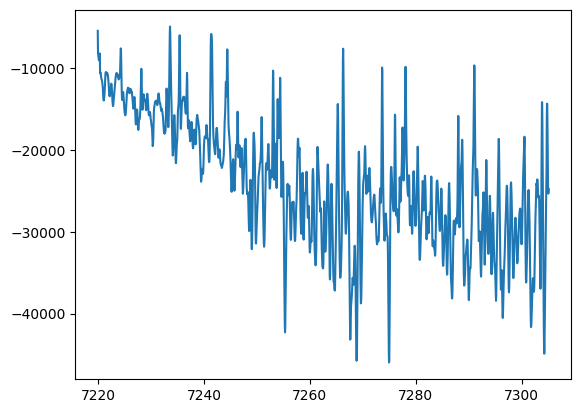

In [27]:
plt.plot(order[:, 0], order[:, 1])

In [28]:
from pybaselines import Baseline, utils

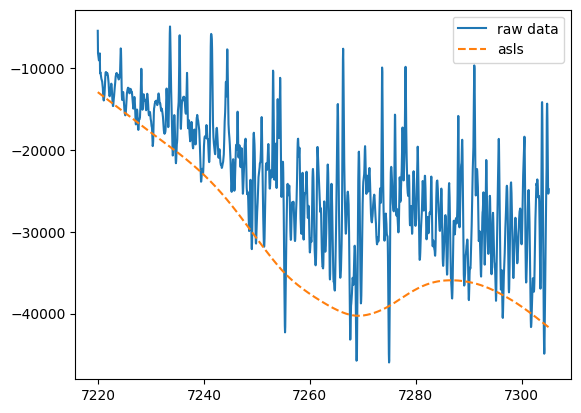

In [29]:

baseline_fitter = Baseline(x_data=order[:, 0])

# bkg_1, params_1 = baseline_fitter.modpoly(order[:, 1], poly_order=3)
bkg_2, params_2 = baseline_fitter.asls(order[:, 1], lam=1e7, p=0.01)
# bkg_3, params_3 = baseline_fitter.mor(order[:, 1], half_window=30)
# bkg_4, params_4 = baseline_fitter.snip(
#     order[:, 1], max_half_window=40, decreasing=True, smooth_half_window=3
# )

plt.plot(order[:, 0], order[:, 1], label='raw data', lw=1.5)
# plt.plot(order[:, 0], bkg_1, '--', label='modpoly')
plt.plot(order[:, 0], bkg_2, '--', label='asls')
# plt.plot(order[:, 0], bkg_3, '--', label='mor')
# plt.plot(order[:, 0], bkg_4, '--', label='snip')

plt.legend()
plt.show()

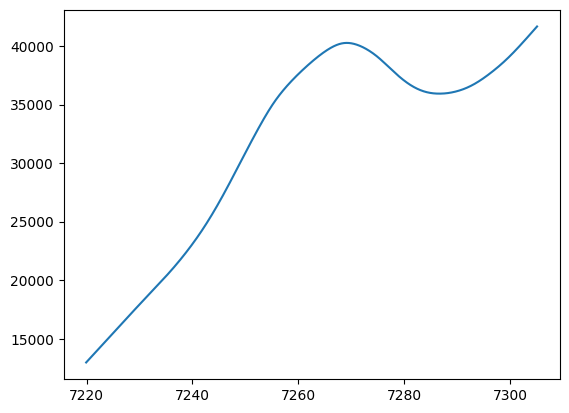

In [30]:
plt.plot(order[:, 0], -bkg_2)

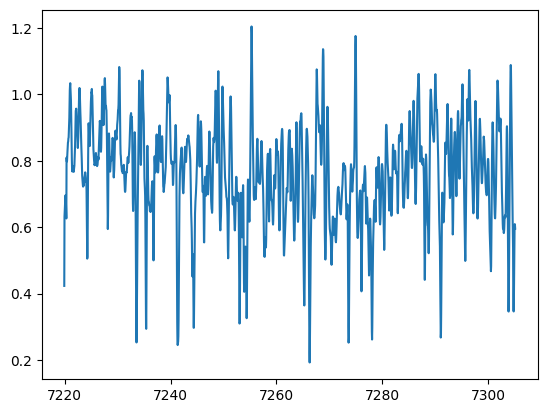

In [31]:
plt.plot(order[:, 0], order[:, 1] / bkg_2)

In [32]:
import numpy as np
import re

def parse_spectrum_file(filename):
    """Парсит файл спектра и извлекает параметры из хедера"""
    # Сначала читаем хедер
    params = {}
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                # Убираем # и разбиваем по :
                key_value = line.strip('#').strip().split(':', 1)
                if len(key_value) == 2:
                    key = key_value[0].strip()
                    value = key_value[1].strip()
                    params[key] = value
            elif not line.startswith('#'):
                # Дошли до данных
                break
    
    # Конвертируем значения в нужные типы
    type_conversions = {
        'teff': float,
        'logg': float,
        '[Fe/H]': float,
        'vmic': float,
        'vmac': float,
        'resolution': float,
        'rotation': float,
        'nlte_flag': lambda x: x.lower() == 'true'
    }
    
    for key, converter in type_conversions.items():
        if key in params:
            try:
                params[key] = converter(params[key])
            except:
                pass
    
    # Читаем данные спектра (пропускаем строки с #)
    data = np.genfromtxt(filename, comments='#')
    
    return data, params

In [33]:
import os
path2grid = "/home/delta/TSFitPy/synthetic_spectra/2026-01-26-20-24-05_0.98384131497766_LTE_synthetic_spectra_parameters"
dir_content = os.listdir(path2grid)
spectra_name_list = [x for x in dir_content if x.find(".spec") != -1]
spectra_params = [x for x in dir_content if x.find(".spec") == -1]
spectra_data = [np.genfromtxt(path2grid + "/" +  x) for x in spectra_name_list]

spectra_data = []


In [34]:
spectra_with_params = [parse_spectrum_file(path2grid + "/" +  filename) for filename in spectra_name_list]

In [35]:
spectra_with_params[0][0][:, 1]

array([0.02539431, 0.01252483, 0.00679355, ..., 0.09444145, 0.07009709,
       0.04562448], shape=(4028,))

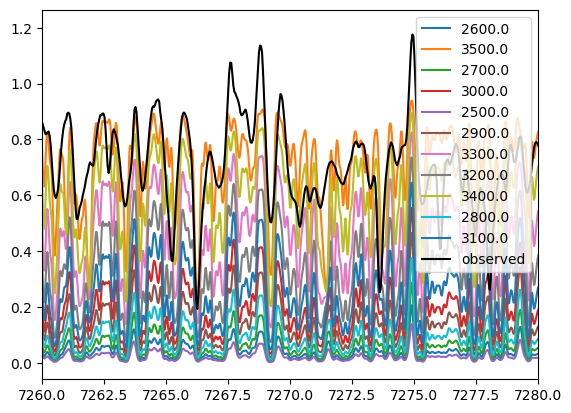

In [36]:
for i in range(len(spectra_with_params)):
    spectrum = spectra_with_params[i][0]
    params = spectra_with_params[i][1]

    plt.plot(spectrum[:, 0], spectrum[:, 1], label=params.get('teff'))
plt.plot(order[:, 0], order[:, 1] / bkg_2, label="observed", color="black")
plt.legend(loc=1)
plt.xlim((7260, 7280))
plt.show()

In [56]:
import os
path2grid_h = "/home/delta/TSFitPy/synthetic_spectra/2026-01-28-19-12-32_0.5548871976111241_LTE_synthetic_spectra_parameters"
dir_content_h = os.listdir(path2grid_h)
spectra_name_list_h = [x for x in dir_content_h if x.find(".spec") != -1]
spectra_params_h = [x for x in dir_content_h if x.find(".spec") == -1]
spectra_data_h = [np.genfromtxt(path2grid + "/" +  x) for x in spectra_name_list_h]

spectra_data = []

In [57]:
spectra_with_params_h = [parse_spectrum_file(path2grid_h + "/" +  filename) for filename in spectra_name_list_h]

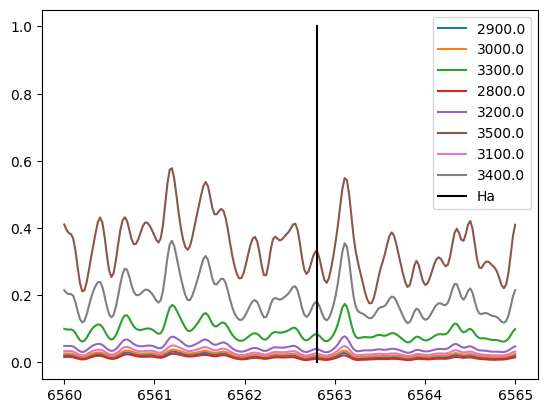

In [ ]:
for i in range(len(spectra_with_params_h)):
    spectrum = spectra_with_params_h[i][0]
    params = spectra_with_params_h[i][1]
    plt.plot(spectrum[:, 0], spectrum[:, 1], label=params.get('teff'))
plt.plot([6562.8, 6562.8], [0, 1], color="black", label="Ha")
plt.legend(loc=1)
# plt.xlim((6562.6, 6563))
plt.show()